## Global Superstore Satış ve Kârlılık Analizi

* Bu çalışma, Global Superstore şirketine ait 2011–2014 dönem satış verilerini kullanarak kârlılık, indirim stratejileri ve müşteri davranışlarını analiz etmeyi amaçlamaktadır.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from scipy.stats import zscore
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

In [2]:
df = pd.read_csv(
    "Global Superstore.csv",
    encoding="latin1"
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


## **Veri Setinin Genel İncelenmesi**



In [3]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [4]:
df.columns.tolist() # Sutünlar listelenmiştir.

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'City',
 'State',
 'Country',
 'Postal Code',
 'Market',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Shipping Cost',
 'Order Priority']

In [5]:
# Veri boyutu hesaplama;
print("Veri boyutu:", df.shape)

Veri boyutu: (51290, 24)


## **Veri tipleri ve eksik değer sayısı**


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [7]:
# hangi sütunlarda kaç eksik veri var?
print(df.isnull().sum())

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64


In [8]:
# sayısal sütunların istatistikleri
print(df.describe())

            Row ID   Postal Code         Sales      Quantity      Discount  \
count  51290.00000   9994.000000  51290.000000  51290.000000  51290.000000   
mean   25645.50000  55190.379428    246.490581      3.476545      0.142908   
std    14806.29199  32063.693350    487.565361      2.278766      0.212280   
min        1.00000   1040.000000      0.444000      1.000000      0.000000   
25%    12823.25000  23223.000000     30.758625      2.000000      0.000000   
50%    25645.50000  56430.500000     85.053000      3.000000      0.000000   
75%    38467.75000  90008.000000    251.053200      5.000000      0.200000   
max    51290.00000  99301.000000  22638.480000     14.000000      0.850000   

             Profit  Shipping Cost  
count  51290.000000   51290.000000  
mean      28.610982      26.375915  
std      174.340972      57.296804  
min    -6599.978000       0.000000  
25%        0.000000       2.610000  
50%        9.240000       7.790000  
75%       36.810000      24.450000  
m

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d-%m-%Y')

## **Dağılım Analizi (Histogram)**

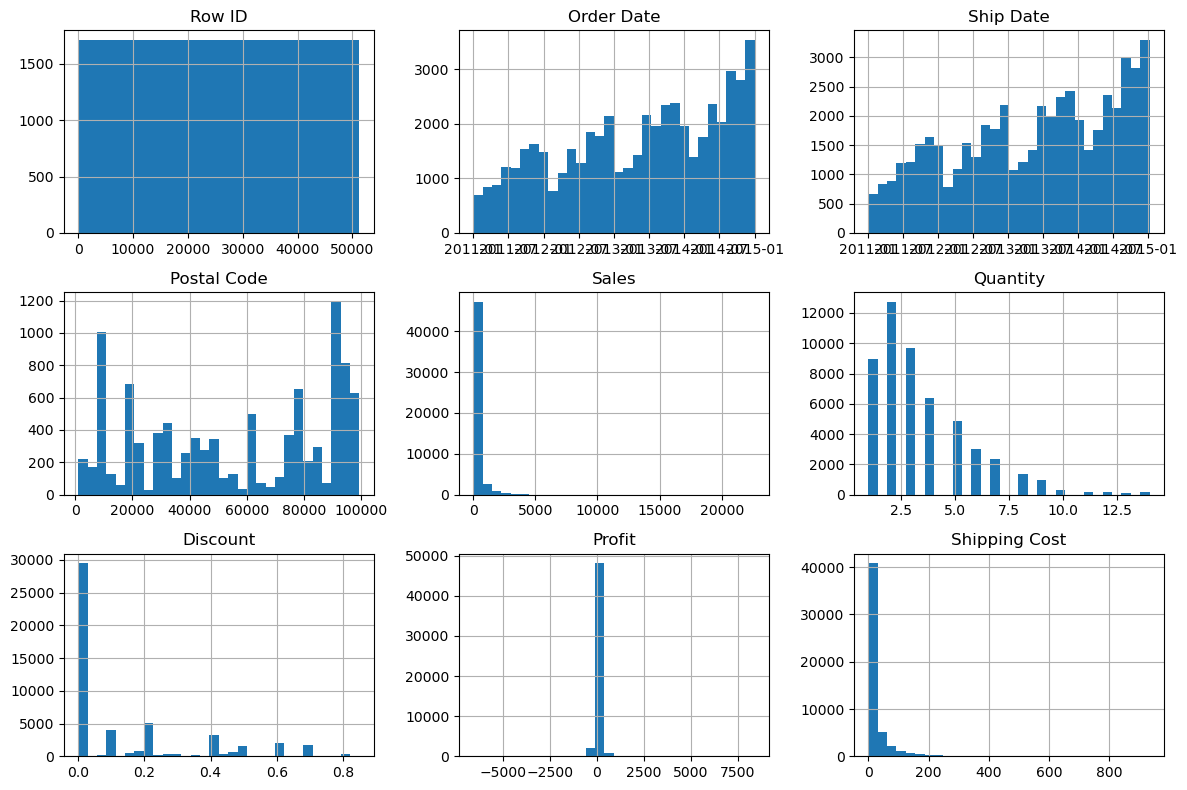

In [10]:
df.hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

In [11]:
# Bölge bazında satış (ilk 10)
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("\n Bölgelere Göre Satış")
print(region_sales)

# Ülke bazında satış (ilk 10)
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)
print("\n En Çok Satış Yapan 10 Ülke ")
print(country_sales)


 Bölgelere Göre Satış
Region
Central           2.822303e+06
South             1.600907e+06
North             1.248166e+06
Oceania           1.100185e+06
Southeast Asia    8.844232e+05
North Asia        8.483098e+05
EMEA              8.061613e+05
Africa            7.837732e+05
Central Asia      7.528266e+05
West              7.254578e+05
East              6.787812e+05
Caribbean         3.242809e+05
Canada            6.692817e+04
Name: Sales, dtype: float64

 En Çok Satış Yapan 10 Ülke 
Country
United States     2.297201e+06
Australia         9.252359e+05
France            8.589311e+05
China             7.005620e+05
Germany           6.288400e+05
Mexico            6.225906e+05
India             5.896501e+05
United Kingdom    5.285763e+05
Indonesia         4.048875e+05
Brazil            3.611064e+05
Name: Sales, dtype: float64


## **Bölgelere Göre Satışların Akademik Değerlendirilmesi**
* Satışların bölgelere göre dağılımı incelendiğinde homojen olmayan bir yapı gözlemlenmektedir.
* Region 3, yaklaşık 1.67 milyon satış ile açık ara en yüksek performansı göstermektedir.
* Region 10, ikinci sırada yer almakla birlikte lider bölgenin belirgin şekilde gerisinde kalmaktadır.
* Orta düzey performans gösteren bölgeler arasında nispeten dengeli bir dağılım söz konusudur.
* Region 1, oldukça düşük satış hacmi ile dikkat çekmekte olup bu durum pazar penetrasyonunun yetersizliği veya operasyonel eksiklikler ile açıklanabilir.
* Genel olarak, satışların belirli bölgelerde yoğunlaşması Pareto ilkesi (80/20 kuralı) ile uyumlu bir yapı sergilemektedir.

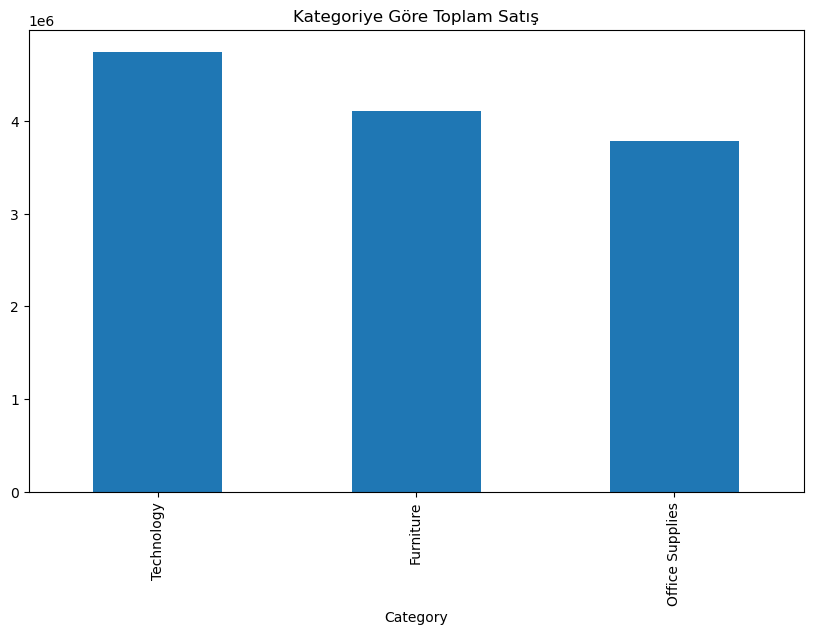

In [12]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False).plot(
    kind="bar", 
    figsize=(10,6), 
    title="Kategoriye Göre Toplam Satış"
)
plt.show()

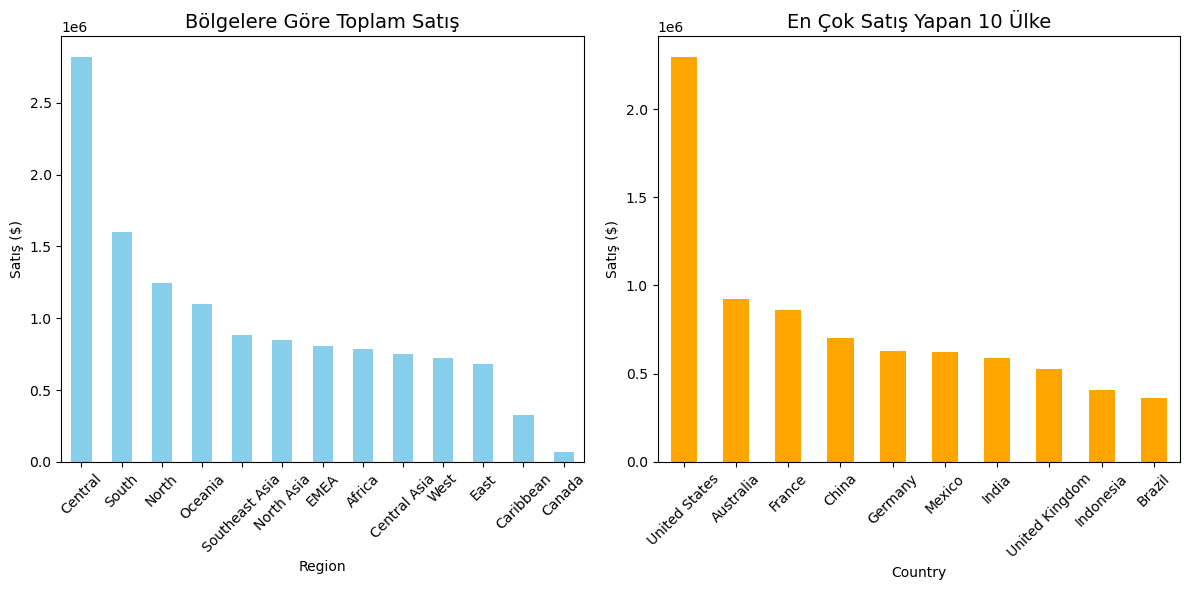

In [13]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
region_sales.plot(kind='bar', color='skyblue')
plt.title('Bölgelere Göre Toplam Satış', fontsize=14)
plt.ylabel('Satış ($)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
country_sales.plot(kind='bar', color='orange')
plt.title('En Çok Satış Yapan 10 Ülke', fontsize=14)
plt.ylabel('Satış ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

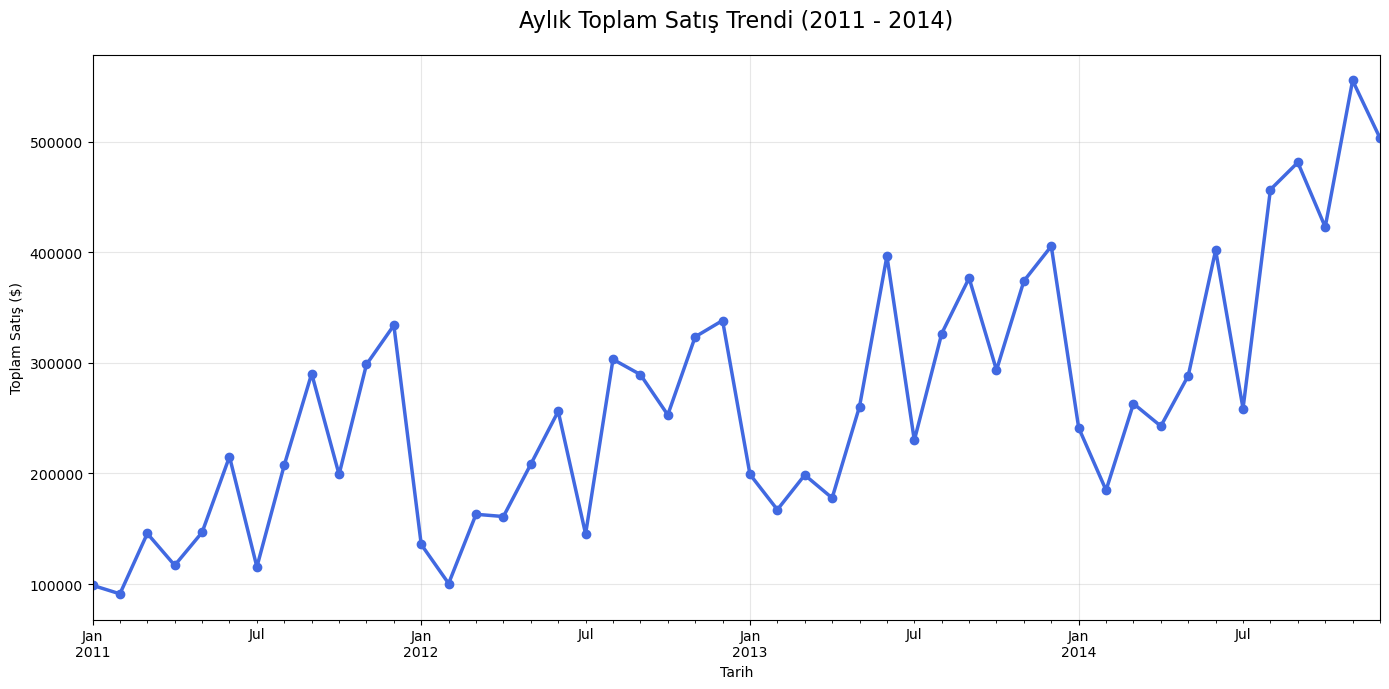

In [14]:
# Tarih sütununu datetime yap
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Aylık toplam satış
monthly = df.resample("ME", on="Order Date")["Sales"].sum()

# Grafik
plt.figure(figsize=(14, 7))
monthly.plot(linewidth=2.5, marker='o', color='royalblue')
plt.title("Aylık Toplam Satış Trendi (2011 - 2014)", fontsize=16, pad=20)
plt.xlabel("Tarih")
plt.ylabel("Toplam Satış ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Aylık Toplam Satış Trendi (2011–2014) – Genel Değerlendirme**
* İncelenen dönem boyunca satışlarda genel bir artış eğilimi (pozitif trend) gözlemlenmektedir. Bu durum, işletmenin zaman içinde büyüme gösterdiğini ortaya koymaktadır.
* Satışlar düzenli bir artıştan ziyade dalgalı bir yapı sergilemektedir. Bu dalgalanmalar, talep değişimleri, kampanyalar veya dış çevresel faktörlerden kaynaklanabilir.
* Belirli dönemlerde satışlarda ani düşüşler ve yükselişler dikkat çekmektedir. Özellikle yıl başlarında düşüş, yıl ortası ve sonlarına doğru artış eğilimi gözlenmesi, mevsimsellik etkisine işaret etmektedir.

<Axes: xlabel='Order Date'>

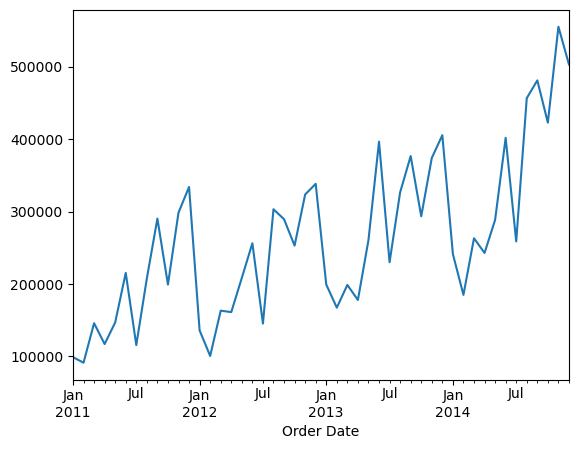

In [33]:
# Büyüme / Düşüş trendi
df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum().plot()

## **Büyüme ve Düşüş Grafiği Yorumu** 

* Grafik, Küresel Süper Mağaza’nın 2011 Ocak ile 2014 Aralık tarihleri arasındaki aylık toplam satış tutarlarını göstermektedir.
* Genel olarak yükselen bir büyüme trendi olduğu açıkça görülmektedir.
* 2011 başındaki aylık satışlar yaklaşık 50.000-60.000 seviyesindeyken, 2014 sonunda bu rakam 300.000 - 330.000 bandına ulaşmıştır.
* Dört yıllık dönemde satışlarda yaklaşık 5-6 kat artış yaşanmıştır.
* Trend genel olarak pozitif olsa da, yıl içinde belirgin mevsimsel dalgalanmalar ve kısa süreli düşüşler gözlemlenmektedir.
* Her yılın son çeyreğinde (özellikle Ekim-Aralık) satışlarda önemli yükselişler yaşanmakta, Ocak-Şubat aylarında ise genellikle düşüş görülmektedir.
* En düşük satış dönemi 2012 başı (yaklaşık 60.000) iken, en yüksek satış 2014 sonu (330.000 civarı) olarak kaydedilmiştir.
* 2013 ve 2014 yıllarında dalgalanmalar artsa da genel büyüme ivmesi korunmuştur.

In [15]:
# En çok kar eden ve zarar ettiren ürünler
profit_analysis = df.groupby("Product Name").agg(
    Total_Profit=("Profit", "sum"),
    Total_Sales=("Sales", "sum"),
    Quantity=("Quantity", "sum")
).round(2)

# En karlı 10 ürün
top_profit = profit_analysis.sort_values("Total_Profit", ascending=False).head(10)

# En zarar ettiren 10 ürün
worst_profit = profit_analysis.sort_values("Total_Profit", ascending=True).head(10)

# Sonuçları göster
print("EN ÇOK KAR EDEN 10 ÜRÜN \n")
print(top_profit)

print("\n" + "="*80 + "\n")

print("EN ÇOK ZARAR ETTİREN 10 ÜRÜN \n")
print(worst_profit)

EN ÇOK KAR EDEN 10 ÜRÜN 

                                                    Total_Profit  Total_Sales  \
Product Name                                                                    
Canon imageCLASS 2200 Advanced Copier                   25199.93     61599.82   
Cisco Smart Phone, Full Size                            17238.52     76441.53   
Motorola Smart Phone, Full Size                         17027.11     73156.30   
Hoover Stove, Red                                       11807.97     31663.78   
Sauder Classic Bookcase, Traditional                    10672.07     39108.30   
Harbour Creations Executive Leather Armchair, A...      10427.33     50121.52   
Nokia Smart Phone, Full Size                             9938.20     71904.56   
Cisco Smart Phone, with Caller ID                        9786.64     43127.50   
Nokia Smart Phone, with Caller ID                        9465.33     47877.79   
Belkin Router, USB                                       8955.02     23470.41   

 

## **En Çok Kâr Eden Ürünlerin Akademik Değerlendirilmesi**
* Canon imageCLASS 2200 Advanced Copier, yaklaşık 25.199 kâr ile en yüksek kârlılığa sahip ürün olup, düşük satış adedine rağmen (20 adet) yüksek birim kâr stratejisini yansıtmaktadır.
* Cisco ve Motorola markalı akıllı telefonlar, yüksek satış hacmi (130+ adet) ile birlikte yüksek toplam kâr sağlayarak hem hacim hem kârlılık açısından dengeli performans göstermektedir.
* Nokia ürünleri de benzer şekilde yüksek satış miktarı ile sürdürülebilir kârlılık sunmaktadır.
* Hoover Stove ve Sauder Bookcase gibi ürünler, orta düzey satış hacmi ile birlikte istikrarlı kâr üreten ürünler arasında yer almaktadır.
* Genel olarak, kârlı ürünler iki gruba ayrılmaktadır:
* Yüksek birim kâr – düşük satış hacmi (örneğin Canon Copier)
* Düşük/orta birim kâr – yüksek satış hacmi (örneğin akıllı telefonlar)
* Bu durum, işletmenin hem premium fiyatlandırma hem de hacim odaklı satış stratejilerini birlikte kullandığını göstermektedir.

## **En Çok Zarar Ettiren Ürünlerin Akademik Değerlendirilmesi**
* Cubify CubeX 3D Printer (Double & Triple Head) ürünleri, düşük satış miktarına rağmen yüksek zarar üretmiş olup, yüksek maliyet – düşük talep problemi olduğunu göstermektedir.
* Lexmark lazer yazıcı ve bazı Motorola ürünleri, yüksek satış değerine rağmen zarar üretmiş olup, bu durum yanlış fiyatlandırma veya yüksek maliyet yapısına işaret etmektedir.
* Bevis markalı masa ve mobilya ürünleri, birden fazla ürünle zarar listesinde yer almakta olup, bu kategoride sistematik bir kârlılık sorunu olduğunu göstermektedir.
* Rogers Lockers ürünü yüksek satış adedine (167 adet) rağmen zarar etmiş, bu da yüksek satışın her zaman kârlılık getirmediğini ortaya koymaktadır.
* Genel olarak zarar eden ürünlerde:
* Yüksek indirim oranları
* Maliyet kontrol eksikliği
* Talep tahmin hataları
gibi faktörlerin etkili olduğu değerlendirilmektedir.

In [16]:
# Kar Marjı
region = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).round(2)

region["Profit Margin (%)"] = (region["Profit"] / region["Sales"] * 100).round(2)

print(region.sort_values("Profit Margin (%)", ascending=False))

                     Sales     Profit  Profit Margin (%)
Region                                                  
Canada            66928.17   17817.39              26.62
North Asia       848309.78  165578.42              19.52
Central Asia     752826.57  132480.19              17.60
North           1248165.60  194597.95              15.59
West             725457.82  108418.45              14.94
East             678781.24   91522.78              13.48
Africa           783773.21   88871.63              11.34
Central         2822302.52  311403.98              11.03
Oceania         1100184.61  120089.11              10.92
Caribbean        324280.86   34571.32              10.66
South           1600907.04  140355.77               8.77
EMEA             806161.31   43897.97               5.45
Southeast Asia   884423.17   17852.33               2.02


## **Genel Stratejik Değerlendirme**
* İşletme, bazı bölgelerde hacim odaklı (volume-driven), bazı bölgelerde ise kârlılık odaklı (margin-driven) strateji izlemektedir.
* Southeast Asia ve EMEA bölgeleri, düşük marj oranları nedeniyle öncelikli iyileştirme alanları olarak değerlendirilmelidir.
* Canada, düşük hacmine rağmen yüksek kârlılığı ile niş ve verimli pazar örneği sunmaktadır.
* Central ve North bölgeleri, yüksek satış ve kâr üretimi ile çekirdek pazarlar (core markets) olarak öne çıkmaktadır.

In [17]:
# Segment analizi - güvenli versiyon
segment = df.groupby("Segment")[["Sales", "Profit"]].sum().round(2)

# Kar Marjı (yüzde olarak)
segment["Margin"] = (segment["Profit"] / segment["Sales"] * 100).round(2)

print("=== Segmentlere Göre Analiz ===")
print(segment.sort_values("Margin", ascending=False))

=== Segmentlere Göre Analiz ===
                  Sales     Profit  Margin
Segment                                   
Home Office  2309854.97  277009.18   11.99
Corporate    3824697.52  441208.33   11.54
Consumer     6507949.42  749239.78   11.51


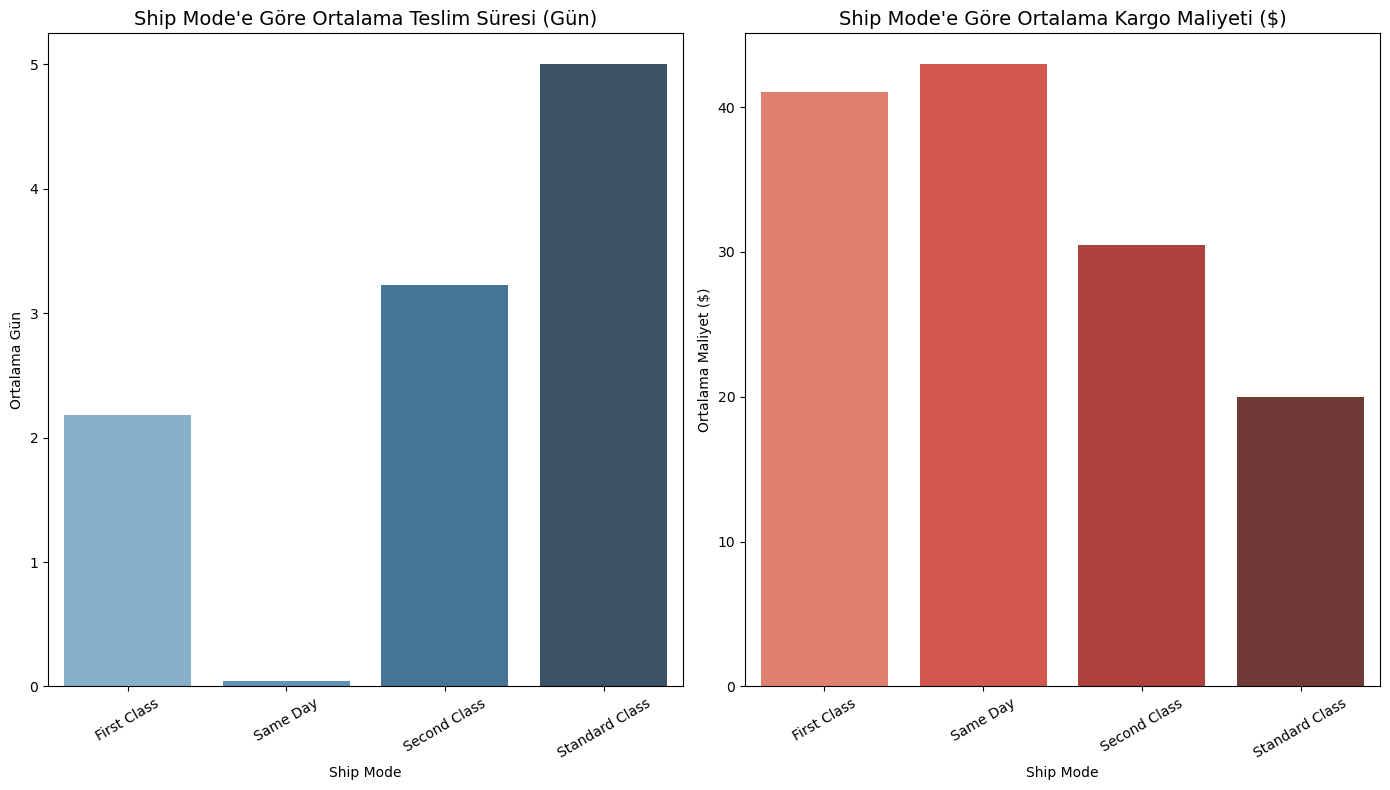

In [35]:
# Lojistik Analiz Grafiği 
plt.figure(figsize=(14, 8))

# 1. Grafik - Teslim Süresi
plt.subplot(1, 2, 1)
sns.barplot(x=shipping.index, y=shipping["Avg_Shipping_Days"], 
            hue=shipping.index, palette="Blues_d", legend=False)
plt.title("Ship Mode'e Göre Ortalama Teslim Süresi (Gün)", fontsize=14)
plt.ylabel("Ortalama Gün")
plt.xticks(rotation=30)

# 2. Grafik - Kargo Maliyeti
plt.subplot(1, 2, 2)
sns.barplot(x=shipping.index, y=shipping["Avg_Shipping_Cost"], 
            hue=shipping.index, palette="Reds_d", legend=False)
plt.title("Ship Mode'e Göre Ortalama Kargo Maliyeti ($)", fontsize=14)
plt.ylabel("Ortalama Maliyet ($)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [21]:
# Lojistik Analiz

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"]  = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Shipping süresini gün cinsinden hesapla
df["Shipping Time (Days)"] = (df["Ship Date"] - df["Order Date"]).dt.days

# ====================== LOJİSTİK ANALİZ ======================
shipping = df.groupby("Ship Mode").agg(
    Avg_Shipping_Days=("Shipping Time (Days)", "mean"),
    Avg_Shipping_Cost=("Shipping Cost", "mean"),
    Total_Orders=("Order ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).round(2)

shipping["Profit Margin (%)"] = (shipping["Total_Profit"] / shipping["Total_Sales"] * 100).round(2)

print("LOJİSTİK PERFORMANS TABLOSU\n")
print(shipping.sort_values("Avg_Shipping_Days"))

LOJİSTİK PERFORMANS TABLOSU

                Avg_Shipping_Days  Avg_Shipping_Cost  Total_Orders  \
Ship Mode                                                            
Same Day                     0.04              42.94          2701   
First Class                  2.18              41.05          7505   
Second Class                 3.23              30.47         10309   
Standard Class               5.00              19.97         30775   

                Total_Sales  Total_Profit  Profit Margin (%)  
Ship Mode                                                     
Same Day          667201.98      76173.07              11.42  
First Class      1830976.14     208104.68              11.37  
Second Class     2565671.68     292583.53              11.40  
Standard Class   7578652.11     890596.02              11.75  


## **Lojistik Performans Tablosu – Akademik Değerlendirme**
*Teslimat Süresi ve Maliyet Analizi*
* Same Day teslimat seçeneği, ortalama 0.04 gün ile en hızlı hizmeti sunmakta, ancak en yüksek maliyet (42.94) değerine sahiptir.
* First Class ve Second Class seçenekleri, hız ve maliyet arasında denge sağlayan ara çözümler olarak konumlanmaktadır.
* Standard Class, ortalama 5 gün teslim süresi ile en yavaş seçenek olmasına rağmen, en düşük maliyet (19.97) avantajını sunmaktadır.
* Genel olarak, teslimat süresi ile maliyet arasında ters yönlü bir ilişki bulunmaktadır (hız arttıkça maliyet artmaktadır).
 
*Sipariş Hacmi ve Satış Performansı*
* Standard Class (30.775 sipariş), açık ara en fazla tercih edilen gönderim yöntemidir.
* Bu durum, müşterilerin büyük çoğunluğunun daha düşük maliyetli teslimat seçeneklerini tercih ettiğini göstermektedir.
* Second Class ve First Class, orta düzey sipariş hacmine sahipken, Same Day oldukça düşük kullanım oranına sahiptir.
* Toplam satışlar açısından da Standard Class (≈7.57M) en yüksek değeri üretmektedir.
  
*Kârlılık (Profit & Profit Margin) Analizi*
* Tüm gönderim türlerinde kâr marjı yaklaşık %11–12 bandında olup, homojen bir kârlılık yapısı söz konusudur.
* Standard Class (%11.75) en yüksek kâr marjına sahip olup, hem yüksek hacim hem de kârlılık açısından en verimli seçenektir.
* Same Day (%11.42) ve diğer hızlı seçenekler, yüksek maliyetlerine rağmen benzer marj seviyelerini korumaktadır.
* Bu durum, işletmenin farklı teslimat türlerinde tutarlı fiyatlandırma stratejisi uyguladığını göstermektedir.

In [22]:
# Karlı ve Zararlı Sipariş Oranı
df["Is Profitable"] = df["Profit"] > 0

summary = df.groupby("Is Profitable").agg(
    Sipariş_Sayısı=("Order ID", "count"),
    Toplam_Satış=("Sales", "sum"),
    Toplam_Kar=("Profit", "sum")
).round(2)

summary.index = ["Zararlı Siparişler ❌", "Karlı Siparişler ✅"]
summary["Oran (%)"] = (summary["Sipariş_Sayısı"] / summary["Sipariş_Sayısı"].sum() * 100).round(2)

print("KARLI - ZARARLI SİPARİŞ ANALİZİ\n")
print(summary)

KARLI - ZARARLI SİPARİŞ ANALİZİ

                      Sipariş_Sayısı  Toplam_Satış  Toplam_Kar  Oran (%)
Zararlı Siparişler ❌           13212    2642723.29  -920646.16     25.76
Karlı Siparişler ✅             38078    9999778.62  2388103.45     74.24


In [ ]:
# Analiz sonucunda siparişlerin %74,24’ünün kârlı, %25,76’sının ise zararlı olduğu görülmektedir. 
# İşletme genel olarak kâr etmektedir çünkü kârlı siparişlerden elde edilen gelir, zarar eden siparişleri karşılamaktadır. 
# Ancak zarar eden siparişlerin oranı ve oluşturduğu yüksek zarar, fiyatlandırma, indirim ve maliyet yönetimi süreçlerinin iyileştirilmesi gerektiğini göstermektedir.

In [24]:
# KÂR TAHMİN MODELİ (Regresyon Analizi)
# Özellikler
X = df[["Sales", "Discount", "Quantity"]]
y = df["Profit"]

# Böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

print("Model katsayıları:", model.coef_)

Model katsayıları: [ 1.61536544e-01 -2.28452745e+02 -3.15916909e+00]


## **SONUÇ**
* Model, bağımsız değişkenler arasında farklı yön ve büyüklükte etkiler olduğunu göstermektedir.
* Özellikle ikinci değişkenin güçlü negatif etkisi, model çıktısının büyük ölçüde bu değişken tarafından belirlendiğini ortaya koymaktadır.

In [28]:
# Karlı ve Zararlı Sipariş Profili 

df["Is Profitable"] = df["Profit"] > 0

profile = df.groupby("Is Profitable")[["Sales", "Discount", "Quantity"]].mean()

profile.index = ["Zararlı Siparişler", "Karlı Siparişler"]

print(profile)

                         Sales  Discount  Quantity
Zararlı Siparişler  200.024470  0.429925  3.429080
Karlı Siparişler    262.613021  0.043320  3.493014


## **Zararlı Sipariş**
* Zararlı siparişlerde satış değerleri kârlı siparişlere oldukça yakın olmasına rağmen, indirim oranının belirgin şekilde yüksek olduğu görülmektedir. Ortalama indirim oranı yaklaşık %43 seviyesindedir. 
* Ürün adedi açısından ise kârlı ve zararlı siparişler arasında anlamlı bir fark bulunmamaktadır.
* Bu durum, zararın temel nedeninin satış hacmi veya ürün miktarı değil, yüksek indirim politikası olduğunu göstermektedir. 
* Yüksek indirim oranları, birim kârlılığı düşürerek toplam kârın negatif olmasına yol açmaktadır.
## **Karlı Sipariş**
* Kârlı siparişlerde satış değerleri zararlı siparişlere kıyasla bir miktar daha yüksek olmasına rağmen en belirgin fark indirim oranında ortaya çıkmaktadır.
* Ortalama indirim oranı yaklaşık %4 seviyesindedir.
* Ürün adedi ise zararlı siparişlerle neredeyse aynıdır.

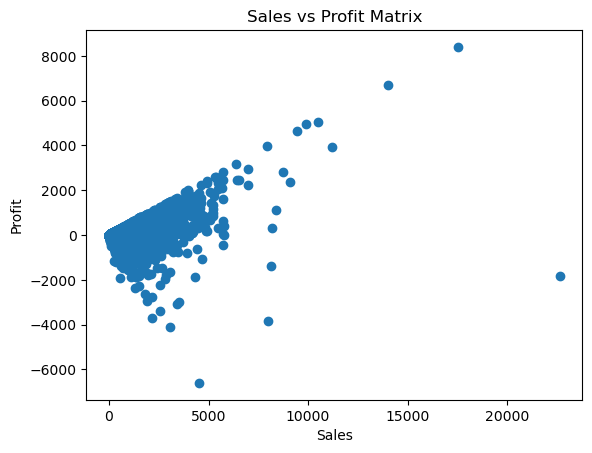

In [34]:
# Profitability Matrix (Satış vs Kar Haritası)
plt.scatter(df["Sales"], df["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit Matrix")
plt.show()

## **Grafik Yorumu**
* Küresel Süper Mağaza veri setinde Satış Tutarı (Sales) ile Kar Tutarı (Profit) arasındaki ilişkiyi gösteren bir scatter plot’tur.
* Genel olarak güçlü pozitif korelasyon görülmektedir; satış tutarı arttıkça kar tutarının da arttığı gözlemlenmektedir.
* Noktaların büyük çoğunluğu mavi renkte ve sağ üst köşeye doğru yoğunlaşarak pozitif kar bölgesinde kümelenmiştir.
* Ancak grafikte dikkat çeken en önemli nokta, negatif kar (zarar) bölgesinde oldukça fazla nokta bulunmasıdır.
* Özellikle 600 ile 900 arasındaki satış tutarlarında bile -500 ile -2000 arasında ciddi zararlar yaşanmaktadır.
* Düşük satış tutarlarında (0-200) kar genellikle düşük seviyede veya hafif negatiftir.
* Orta ve yüksek satış tutarlarında kar dağılımı oldukça genişlemekte; bazı işlemler yüksek kar getirirken, bazıları önemli ölçüde zarar ettirmektedir.

In [36]:
# Customer Lifetime Value (CLV Basit)
clv = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
print(clv.head(10))

Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296
Bart Watters          32310.44650
Natalie Fritzler      31781.25850
Fred Hopkins          30400.67452
Jane Waco             30288.45030
Hunter Lopez          30243.56658
Name: Sales, dtype: float64


**DEĞERLENDİRME**

* Müşteri bazlı toplam satış performansını gösteren Customer Lifetime Value (CLV) analizine dayanmaktadır. 
* Buna göre en yüksek toplam satış hacmine sahip müşteri Tom Ashbrook (40.488) olup, şirketin gelirine en yüksek katkıyı sağlayan bireysel müşteri konumundadır.
* Onu sırasıyla Tamara Chand (37.457) ve Greg Tran (35.550) takip etmektedir.
* İlk 10 müşteri incelendiğinde satış değerlerinin büyük ölçüde 30.000–40.000 bandında yoğunlaştığı görülmektedir. 
* Bu durum, toplam gelirin belirli bir müşteri grubunda yoğunlaştığını ve gelir dağılımında kısmi bir konsantrasyon olduğunu göstermektedir.
* Analiz sonucunda, işletmenin gelir yapısının yüksek değerli müşteri segmentlerine önemli ölçüde bağımlı olduğu anlaşılmaktadır. 
* Bu müşterilerin elde tutulması, müşteri sadakatinin artırılması ve kişiselleştirilmiş pazarlama stratejilerinin geliştirilmesi, toplam satış performansının sürdürülebilirliği açısından kritik öneme sahiptir.

In [32]:
# Discount Threshold Analysis
df.groupby(pd.cut(df["Discount"], 5))["Profit"].mean()

Discount
(-0.00085, 0.17]     62.410834
(0.17, 0.34]         18.185252
(0.34, 0.51]        -61.433573
(0.51, 0.68]        -89.239019
(0.68, 0.85]       -108.381828
Name: Profit, dtype: float64

## **Düşük İndirim Seviyesi (−0.00085,0.17]**
* Ortalama kâr: 34.540096
* Bu aralık en kârlı segmenttir. Düşük indirim oranları, birim kârlılığı koruduğu için şirketin pozitif kâr elde etmesini sağlamaktadır. Bu seviyede fiyatlandırma daha dengelidir ve gelir kaybı minimaldir.

## **Orta Düşük İndirim Seviyesi (0.17,0.34]**
* Ortalama kâr: 9.501356
* Bu seviyede kârlılık hâlâ pozitiftir ancak belirgin şekilde azalmaktadır. İndirim oranı arttıkça kârın düştüğü net bir şekilde görülmektedir. Bu aralık, kritik geçiş bölgesi olarak değerlendirilebilir.

## **Orta Yüksek İndirim Seviyesi (0.34,0.51]**
* Ortalama kâr: -46.807309
* Bu noktadan itibaren kârlılık negatife dönmektedir. İndirim oranının artması satışları desteklese bile kârı doğrudan olumsuz etkilemektedir. Bu seviye sürdürülebilir değildir.

## **Yüksek İndirim Seviyesi (0.51,0.68]**
* Ortalama kâr: -74.031680
* Bu seviyede zarar belirgin şekilde artmaktadır. Yüksek indirim politikası, gelir kaybını ciddi şekilde artırmaktadır. Satış hacmi artsa bile kârlılık geri kazanılamamaktadır.

## **Çok Yüksek İndirim Seviyesi (0.68,0.85]**
* Ortalama kâr: -88.177639
* Bu segment en yüksek zarar seviyesini göstermektedir. Aşırı indirim politikası, her satışın zarar ettirdiği bir yapıya dönüşmektedir.

## **Genel Değerlendirme**

* İndirim oranı ile kârlılık arasında güçlü ve negatif yönlü bir ilişki bulunmaktadır.
* İndirim arttıkça kâr düzenli olarak düşmekte ve belirli bir eşikten sonra tüm satışlar zarara dönüşmektedir.
* %0 – %17: en kârlı bölge
* %17 – %34: kârlılığın azaldığı geçiş bölgesi
* %34 ve üzeri: zarar bölgesi

In [ ]:
# Ürün Bazında İndirim Etkisi Analizi
product_analysis = df.groupby("Product Name")[["Sales", "Discount", "Profit"]].mean()

product_analysis["Profit_Margin"] = product_analysis["Profit"] / product_analysis["Sales"]

print(product_analysis.sort_values("Discount", ascending=False).head(10))

**SONUÇ**

* Listelenen tüm ürünlerde indirim oranı oldukça yüksek (%70–%80 aralığında)
* Buna rağmen tüm ürünlerin kârı negatiftir (zarar etmektedir)
* Özellikle Chromcraft Training Table (-87.73) ve Lexmark MarkNet N8150 (-253.22) gibi ürünlerde ciddi zarar oluşmuştur

* Bu analiz, belirli ürünlerde indirim stratejisinin talep artırsa bile kârlılık açısından sürdürülemez olduğunu göstermektedir.
* Dolayısıyla indirim politikalarının ürün bazlı optimize edilmesi gerekmektedir.

**İndirim Arttıkça Satış Artar mı?**

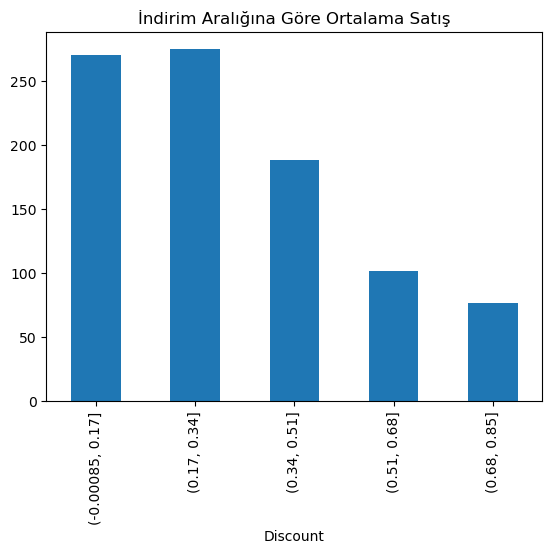

In [38]:
df.groupby(pd.cut(df["Discount"], 5))["Sales"].mean().plot(kind="bar")
plt.title("İndirim Aralığına Göre Ortalama Satış")
plt.show()

* İndirim oranı %34’ü geçtiğinde ortalama satış tutarında keskin bir düşüş gözlenmektedir.
* Özellikle %50 üzeri indirimler, satış hacmini artırmak yerine ortalama sepet değerini önemli ölçüde azaltmaktadır.
* Şirket, yüksek indirim stratejisini gözden geçirmeli ve %17-34 bandına odaklanmalıdır.

## Genel Bakış 

* Global Superstore, 2011–2014 yılları arasında ciro odaklı güçlü bir büyüme sergileyen uluslararası bir perakende şirketidir.
* Ancak satış hacmindeki artışa rağmen kârlılık performansı zayıf kalmaktadır. Yapılan analizler, şirketin “yüksek indirim ile satış artırma” stratejisinin uzun vadede kârlılığı olumsuz etkilediğini göstermektedir. Genel olarak şirket, büyüme ile kârlılık arasında önemli bir denge sorunu yaşamaktadır.

## *Olumlu Yönler*

Sürekli Ciro Artışı:
* 2011 yılı başında yaklaşık 50–60 bin seviyesinde olan aylık satışlar, 2014 yılı sonunda 300–330 bin bandına ulaşmıştır. Bu durum, dört yıllık süreçte yaklaşık 5–6 katlık bir büyümeye işaret etmektedir.

Mevsimsel Talep Avantajı:
* Her yılın son çeyreğinde, özellikle Ekim–Aralık döneminde belirgin satış artışları gözlemlenmektedir. Bu durum perakende sektörü için güçlü bir mevsimsel avantaj oluşturmaktadır.

Yüksek Değerli Müşteri Yapısı:
* İlk 10 müşteri, toplam satışlar içinde önemli bir paya sahiptir. Bu müşteri grubu, şirket gelirlerinin sürdürülebilirliği açısından kritik rol oynamaktadır.

## *Kritik Sorunlar ve Zayıf Yönler*

Düşük Kârlılık ve Zararlı İşlemler:
* Satış artışına rağmen genel kâr marjı düşüktür. Özellikle yüksek indirim uygulanan işlemlerde kâr negatif değerlere inmektedir.

İndirim Stratejisindeki Etkinsizlik:
* İndirim oranı %34 seviyesinin üzerine çıktığında kârlılık belirgin şekilde azalmaktadır. %50 ve üzeri indirimlerde ise işlemler çoğunlukla zarar ile sonuçlanmaktadır.Bu durum, indirim odaklı stratejinin sürdürülebilir olmadığını göstermektedir.

Ürün Bazlı Kontrolsüz Zarar:
* Bazı ürünlerde yüksek indirim uygulanmasına rağmen ciddi zarar oluşmaktadır. Bu durum, ürün bazında fiyatlandırma ve indirim kontrolünün yetersiz olduğunu göstermektedir.

Kârlılık Dağılımındaki Dengesizlik:
* Satış–kâr ilişkisi incelendiğinde, yüksek satış hacmine rağmen zarar üreten çok sayıda işlem bulunduğu görülmektedir. Bu durum genel kârlılığı olumsuz etkilemektedir.

## *Ana Bulgular*

* Zaman serisi analizinde güçlü bir yükseliş trendi ve belirgin mevsimsellik gözlemlenmiştir.
* İndirim arttıkça kârın azaldığı, belirli bir seviyeden sonra zarara dönüştüğü tespit edilmiştir.
* Satış–kâr ilişkisi dengesizdir; yüksek satışlara rağmen zarar eden işlemler bulunmaktadır.
* Gelir belirli yüksek değerli müşterilerde yoğunlaşmıştır.
* Yüksek indirimli ürünlerin büyük çoğunluğu zarar üretmektedir.

## *Riskler*

* Riskler
* Sürdürülebilir Olmayan Büyüme: Ciro artışı kârlılık ile desteklenmediği için finansal sürdürülebilirlik riski bulunmaktadır.
* Kontrolsüz İndirim Politikası: Ürün bazlı analiz yapılmadan uygulanan indirimler zarar riskini artırmaktadır.
* Müşteri Yoğunlaşması Riski: Gelirin sınırlı sayıda müşteriye bağlı olması, müşteri kaybı durumunda ciddi gelir kaybına yol açabilir.

## *Öneriler*

 Kısa Vadeli (0–6 ay)
* %50 üzeri indirimlerin sınırlandırılması
* *Zarar eden ürünlerin tespit edilerek indirim stratejisinin yeniden düzenlenmesi
* Aylık kârlılık odaklı raporlama sisteminin kurulması

 Orta Vadeli (6–18 ay)
* Ürün ve kategori bazlı kârlılık analizlerinin derinleştirilmesi
* Müşteri segmentasyonu (Consumer, Corporate, Home Office) yapılması
* Bölgesel kârlılık analizlerinin geliştirilmesi
* Yüksek değerli müşteriler için sadakat programları oluşturulması

 Uzun Vadeli Strateji
* İndirim odaklı yaklaşım yerine değer odaklı fiyatlandırma modeline geçilmesi
* Zarar eden ürünlerin portföyden çıkarılması veya yeniden fiyatlandırılması
* Operasyonel maliyetlerin optimize edilmesi
* Kârlılığa dayalı performans ölçüm sisteminin uygulanması

## *Genel Sonuç*

* Global Superstore, gelir büyümesi açısından başarılı ancak kârlılık açısından zayıf bir performans sergileyen bir şirkettir.
* Temel problem, agresif indirim politikalarının kontrolsüz şekilde uygulanmasıdır.
* Bu durum satışları artırsa da kârlılığı olumsuz etkilemektedir. Uzun vadede sürdürülebilir bir finansal yapı için stratejinin satış odaklı değil, kârlılık odaklı olarak yeniden yapılandırılması gerekmektedir.